In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist

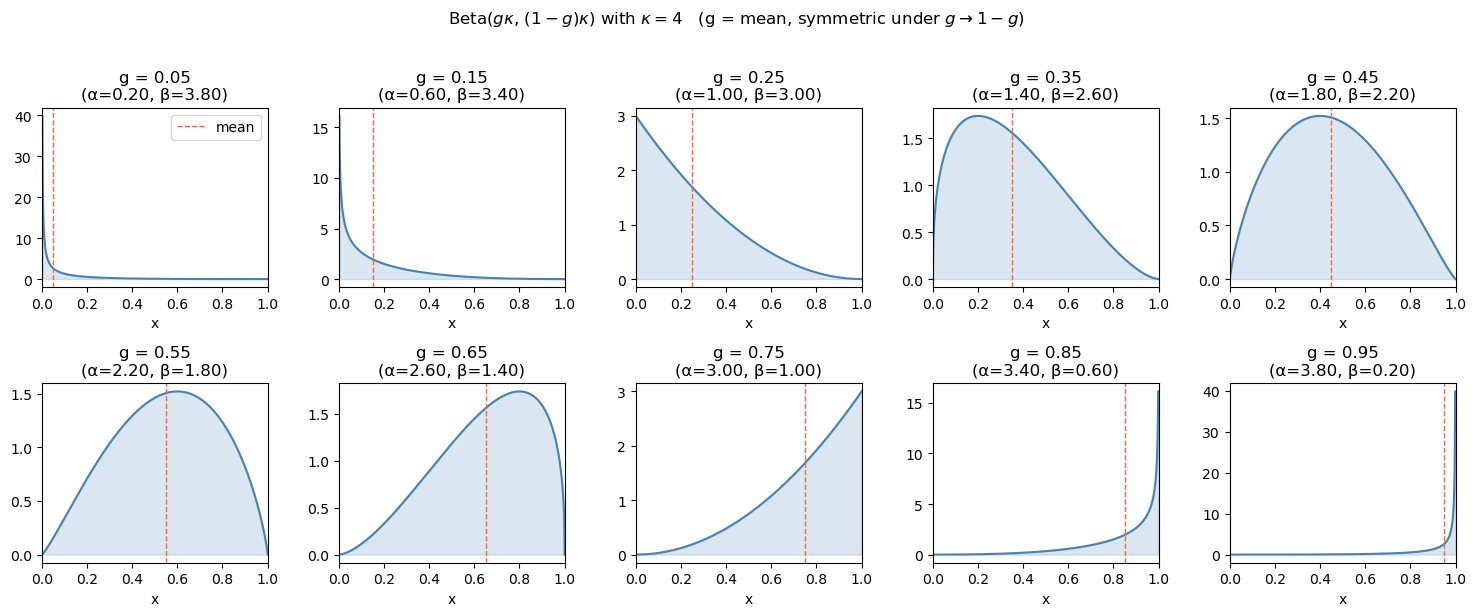

In [10]:
# Parameterisation: fix total concentration kappa = alpha + beta,
# set alpha = g * kappa, beta = (1 - g) * kappa.
# This gives mean = g and is symmetric under (g -> 1-g, x -> 1-x).
# kappa = 4 so that alpha = beta = 2 at g = 0.5.
kappa = 4
g_values = np.linspace(0.05, 0.95, 10)

x = np.linspace(0, 1, 500)

n_cols = 5
n_rows = int(np.ceil(len(g_values) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows), sharey=False)
axes = axes.flatten()

for i, g in enumerate(g_values):
    a = g * kappa
    b = (1 - g) * kappa
    pdf = beta_dist.pdf(x, a, b)
    axes[i].plot(x, pdf, color='steelblue')
    axes[i].fill_between(x, pdf, alpha=0.2, color='steelblue')
    axes[i].set_title(f'g = {g:.2f}\n(α={a:.2f}, β={b:.2f})')
    axes[i].set_xlabel('x')
    axes[i].set_xlim(0, 1)
    axes[i].axvline(g, color='tomato', linestyle='--', linewidth=1, label='mean')

axes[0].legend()

for ax in axes[len(g_values):]:
    ax.set_visible(False)

fig.suptitle(r'Beta($g\kappa$, $(1-g)\kappa$) with $\kappa=4$   (g = mean, symmetric under $g\to1-g$)', y=1.02)
fig.tight_layout()
plt.show()

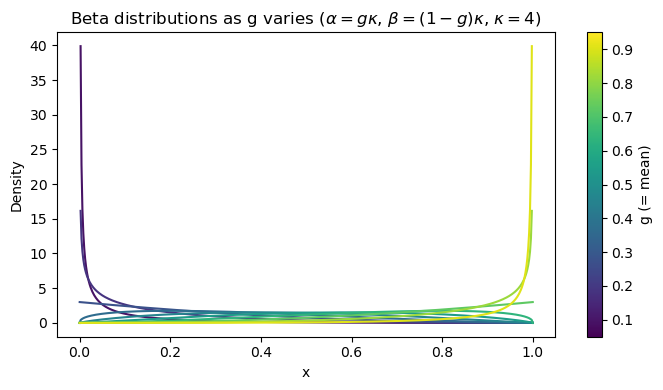

In [11]:
# Overlay all curves on a single axes for comparison
cmap = plt.cm.viridis
colors = [cmap(g) for g in g_values]

fig, ax = plt.subplots(figsize=(7, 4))
for g, color in zip(g_values, colors):
    a = g * kappa
    b = (1 - g) * kappa
    pdf = beta_dist.pdf(x, a, b)
    ax.plot(x, pdf, color=color, label=f'g={g:.2f}')

ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.set_title(r'Beta distributions as g varies ($\alpha=g\kappa$, $\beta=(1-g)\kappa$, $\kappa=4$)')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(g_values.min(), g_values.max()))
sm.set_array([])
fig.colorbar(sm, ax=ax, label='g (= mean)')
fig.tight_layout()
plt.show()